Take peak, bin till you get histogram of course vs fine (x-axis) counts to find optimal ranges of a peak

In [1]:
import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import apav

from peak_detection.data_io import parse_rrng

APT_PATH = "data/APT_test/R15_72243.apt"
RRNG_PATH = "data/RRNG_test/R15_72243.RRNG"

print(f"apav version: {apav.__version__}")
print(f"APT file exists: {os.path.exists(APT_PATH)} -> {APT_PATH}")
print(f"RRNG file exists: {os.path.exists(RRNG_PATH)} -> {RRNG_PATH}")


apav version: 1.4.0
APT file exists: True -> data/APT_test/R15_72243.apt
RRNG file exists: True -> data/RRNG_test/R15_72243.RRNG


## 1. Load human-labeled peak ranges

In [2]:
peaks, elements = parse_rrng(RRNG_PATH)
peaks = sorted(peaks, key=lambda p: p.start)

print(f"Loaded {len(peaks)} labeled peaks")
print(f"Elements present: {sorted(elements)}\n")
print(f"{'idx':>3s} {'label':10s} {'start':>8s} {'end':>8s} {'width':>7s}")
for i, p in enumerate(peaks):
    print(f"{i:3d} {p.label:10s} {p.start:8.4f} {p.end:8.4f} {p.end - p.start:7.4f}")


Loaded 21 labeled peaks
Elements present: ['C', 'Cu', 'Fe', 'H', 'N', 'O', 'S', 'Si']

idx label         start      end   width
  0 H            0.9950   1.0330  0.0380
  1 C            5.9730   6.0410  0.0680
  2 C           11.9540  12.0480  0.0940
  3 Si          13.9520  14.0360  0.0840
  4 O           15.9640  16.0440  0.0800
  5 C3          17.9710  18.0110  0.0400
  6 Fe          18.6140  18.6630  0.0490
  7 C2          23.9550  24.0480  0.0930
  8 CN          25.9840  26.0150  0.0310
  9 Fe          26.8540  27.0850  0.2310
 10 Fe          27.7100  28.1750  0.4650
 11 Unknown     28.2100  28.3500  0.1400
 12 Fe          28.4000  28.5950  0.1950
 13 Fe          28.9250  29.0300  0.1050
 14 Cu          31.3950  31.5500  0.1550
 15 S           31.9550  31.9950  0.0400
 16 Cu          32.4000  32.5550  0.1550
 17 Unknown     34.9450  34.9750  0.0300
 18 Fe          55.7710  56.6900  0.9190
 19 Cu          62.7950  63.1500  0.3550
 20 Cu          64.8400  65.1600  0.3200


## 2. Load raw ion hit list

Loaded via `apav` directly (not `load_apt_from_file`, which locks bin_width to 0.01) so we can rebin at arbitrary widths later.

In [3]:
roi = apav.load_apt(APT_PATH)

mass_lo, mass_hi = roi.mass_extents
print(f"Loaded ROI from {APT_PATH}")
print(f"Total ion count: {len(roi.mass):,}")
print(f"Mass range: {mass_lo:.4f} - {mass_hi:.4f} Da")


Loaded ROI from data/APT_test/R15_72243.apt
Total ion count: 2,732,250
Mass range: 0.0000 - 257.4726 Da


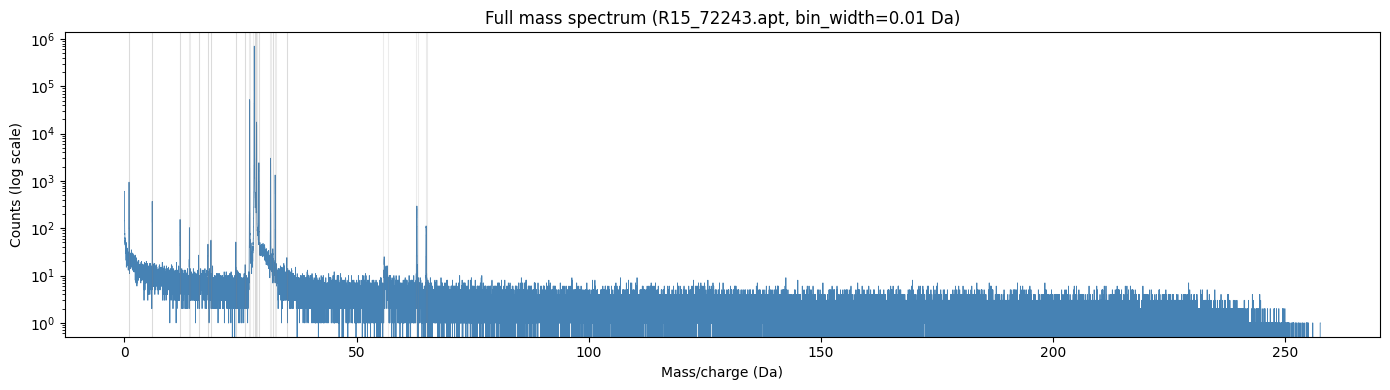

Full spectrum: 25,748 bins, total counts=2,732,250
Max bin count=705,172 at 27.965 Da


In [4]:
x_full, counts_full = roi.mass_histogram(bin_width=0.01, lower=0, upper=mass_hi, multiplicity='all', norm=False)

fig, ax = plt.subplots(figsize=(14, 4))
ax.step(x_full, counts_full, where='mid', linewidth=0.6, color='steelblue')
for p in peaks:
    ax.axvline(p.start, color='gray', linestyle='-', alpha=0.15, linewidth=0.8)
    ax.axvline(p.end, color='gray', linestyle='-', alpha=0.15, linewidth=0.8)
ax.set_yscale('log')
ax.set_xlabel("Mass/charge (Da)")
ax.set_ylabel("Counts (log scale)")
ax.set_title(f"Full mass spectrum ({os.path.basename(APT_PATH)}, bin_width=0.01 Da)")
plt.tight_layout()
plt.show()

print(f"Full spectrum: {len(x_full):,} bins, total counts={counts_full.sum():,.0f}")
print(f"Max bin count={counts_full.max():,.0f} at {x_full[np.argmax(counts_full)]:.3f} Da")


## 3. Compute ±0.5 Da windows

Each window is a fixed 0.5 Da margin padded onto the peak's (or peak group's) labeled start/end.

- **Case 1** — isolated `C` peak (~12 Da): baseline sanity check.
- **Case 2** — the tight Fe multiplet cluster (~27-29 Da): the harder case where labels nearly touch.

In [5]:
MARGIN = 0.5  # Da

# Case 1: isolated single peak (baseline sanity check)
c_idx = next(i for i, p in enumerate(peaks) if p.label == "C" and p.start > 10)
c_window = (peaks[c_idx].start - MARGIN, peaks[c_idx].end + MARGIN)
print(f"Case 1 - isolated 'C' peak (idx {c_idx}): label range [{peaks[c_idx].start:.4f}, {peaks[c_idx].end:.4f}]")
print(f"  +/-{MARGIN} Da window: [{c_window[0]:.4f}, {c_window[1]:.4f}]  (width {c_window[1] - c_window[0]:.4f} Da)\n")

# Case 2: tight Fe multiplet cluster
fe_cluster_idx = [i for i, p in enumerate(peaks) if 26.8 <= p.start <= 29.1]
fe_window = (peaks[fe_cluster_idx[0]].start - MARGIN, peaks[fe_cluster_idx[-1]].end + MARGIN)
print(f"Case 2 - Fe multiplet cluster (idx {fe_cluster_idx}):")
for i in fe_cluster_idx:
    print(f"  {peaks[i].label:10s} [{peaks[i].start:.4f}, {peaks[i].end:.4f}]")
print(f"  +/-{MARGIN} Da window: [{fe_window[0]:.4f}, {fe_window[1]:.4f}]  (width {fe_window[1] - fe_window[0]:.4f} Da)")


Case 1 - isolated 'C' peak (idx 2): label range [11.9540, 12.0480]
  +/-0.5 Da window: [11.4540, 12.5480]  (width 1.0940 Da)

Case 2 - Fe multiplet cluster (idx [9, 10, 11, 12, 13]):
  Fe         [26.8540, 27.0850]
  Fe         [27.7100, 28.1750]
  Unknown    [28.2100, 28.3500]
  Fe         [28.4000, 28.5950]
  Fe         [28.9250, 29.0300]
  +/-0.5 Da window: [26.3540, 29.5300]  (width 3.1760 Da)


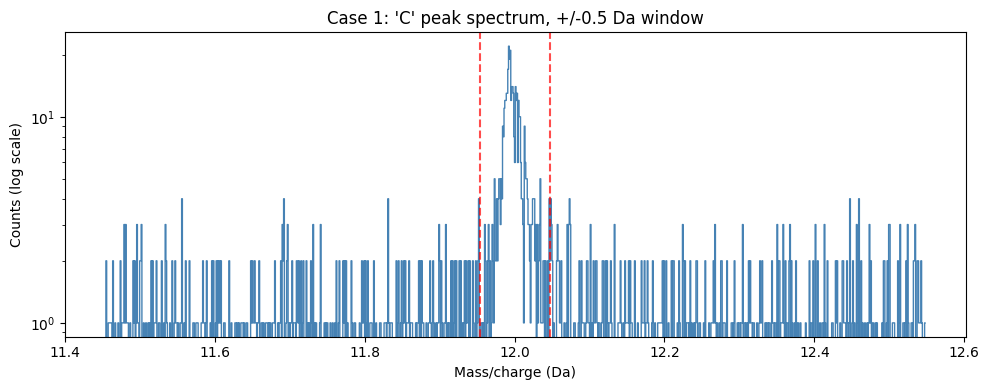

Case 1: 'C' peak spectrum, +/-0.5 Da window: window [11.4540, 12.5480], bin_width=0.001 Da, 1,094 bins, total counts=1,245


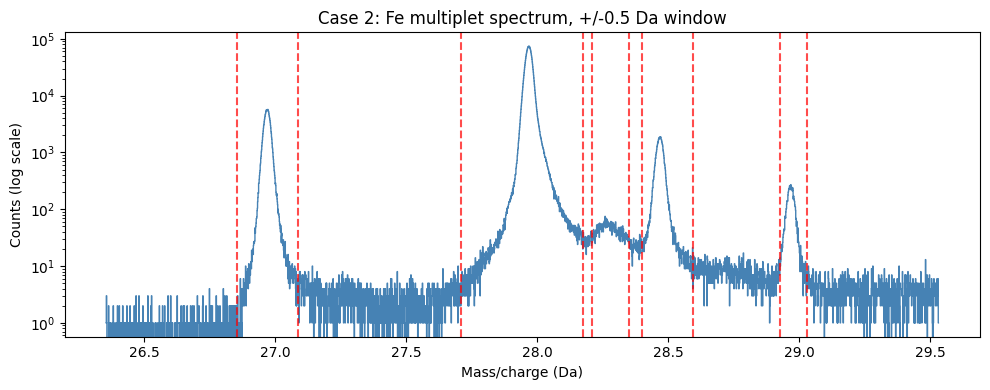

Case 2: Fe multiplet spectrum, +/-0.5 Da window: window [26.3540, 29.5300], bin_width=0.001 Da, 3,177 bins, total counts=2,625,702


In [6]:
def plot_region_spectrum(roi, window, labels_in_window, title, bin_width=0.001):
    x, counts = roi.mass_histogram(bin_width=bin_width, lower=window[0], upper=window[1],
                                    multiplicity='all', norm=False)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.step(x, counts, where='mid', color='steelblue', linewidth=1.0)
    ax.set_yscale('log')
    for p in labels_in_window:
        ax.axvline(p.start, color='red', linestyle='--', alpha=0.7)
        ax.axvline(p.end, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel("Mass/charge (Da)")
    ax.set_ylabel("Counts (log scale)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    print(f"{title}: window [{window[0]:.4f}, {window[1]:.4f}], bin_width={bin_width} Da, "
          f"{len(x):,} bins, total counts={counts.sum():,.0f}")


plot_region_spectrum(roi, c_window, [peaks[c_idx]], "Case 1: 'C' peak spectrum, +/-0.5 Da window")
plot_region_spectrum(roi, fe_window, [peaks[i] for i in fe_cluster_idx], "Case 2: Fe multiplet spectrum, +/-0.5 Da window")


## 4. Multi-resolution binning sweep

Rebin each window at bin widths from 0.001 Da (fine) up to 0.05 Da (coarse).

In [7]:
BIN_WIDTHS = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]  # Da, fine -> coarse


def binning_sweep(roi, window_start, window_end, bin_widths=BIN_WIDTHS):
    """Rebin the window at each bin width. Returns {bin_width: (x, counts)}."""
    results = {}
    for w in bin_widths:
        x, counts = roi.mass_histogram(bin_width=w, lower=window_start, upper=window_end,
                                        multiplicity='all', norm=False)
        results[w] = (x, counts)
        print(f"  bin_width={w:6.3f} Da -> {len(x):5d} bins, total counts={counts.sum():.0f}, "
              f"peak bin count={counts.max():.0f}")
    return results


print("Case 1 - 'C' peak sweep:")
c_sweep = binning_sweep(roi, *c_window)

print("\nCase 2 - Fe multiplet sweep:")
fe_sweep = binning_sweep(roi, *fe_window)


Case 1 - 'C' peak sweep:
  bin_width= 0.001 Da ->  1094 bins, total counts=1245, peak bin count=22
  bin_width= 0.002 Da ->   547 bins, total counts=1245, peak bin count=41
  bin_width= 0.005 Da ->   219 bins, total counts=1246, peak bin count=84
  bin_width= 0.010 Da ->   110 bins, total counts=1248, peak bin count=136
  bin_width= 0.020 Da ->    55 bins, total counts=1248, peak bin count=192
  bin_width= 0.050 Da ->    22 bins, total counts=1248, peak bin count=327

Case 2 - Fe multiplet sweep:
  bin_width= 0.001 Da ->  3177 bins, total counts=2625702, peak bin count=74296
  bin_width= 0.002 Da ->  1589 bins, total counts=2625708, peak bin count=148070
  bin_width= 0.005 Da ->   636 bins, total counts=2625717, peak bin count=366845
  bin_width= 0.010 Da ->   318 bins, total counts=2625717, peak bin count=713635
  bin_width= 0.020 Da ->   159 bins, total counts=2625717, peak bin count=1281668
  bin_width= 0.050 Da ->    64 bins, total counts=2625781, peak bin count=1945753


## 5. Plot 1 — overlaid histograms (mass on x, counts on y)

One line per bin width, human label boundaries drawn as vertical dashed lines.

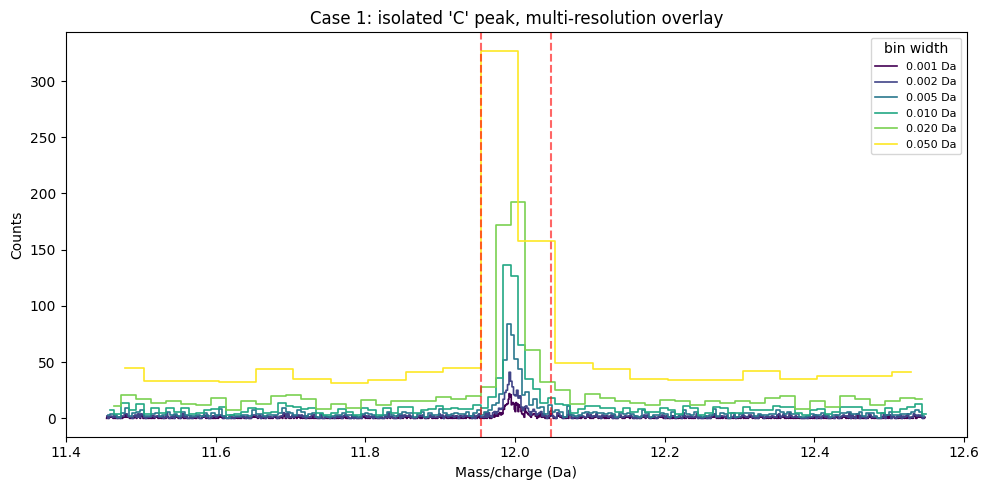

Plotted 'Case 1: isolated 'C' peak, multi-resolution overlay' with 1 label boundary marker(s)


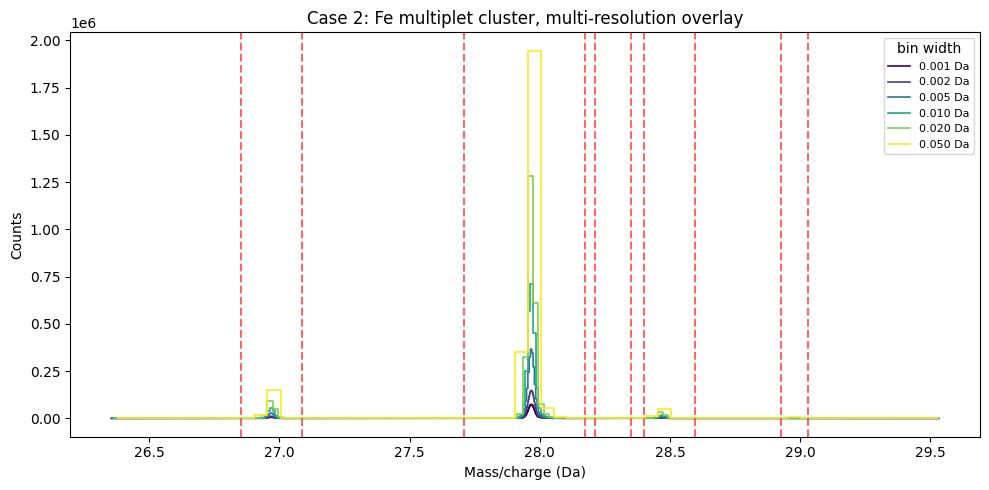

Plotted 'Case 2: Fe multiplet cluster, multi-resolution overlay' with 5 label boundary marker(s)


In [8]:
def plot_overlay(sweep, labels_in_window, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.viridis(np.linspace(0, 1, len(sweep)))
    for color, (w, (x, counts)) in zip(colors, sweep.items()):
        ax.step(x, counts, where='mid', label=f"{w:.3f} Da", color=color, linewidth=1.2)
    for p in labels_in_window:
        ax.axvline(p.start, color='red', linestyle='--', alpha=0.6)
        ax.axvline(p.end, color='red', linestyle='--', alpha=0.6)
    ax.set_xlabel("Mass/charge (Da)")
    ax.set_ylabel("Counts")
    ax.set_title(title)
    ax.legend(title="bin width", fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f"Plotted '{title}' with {len(labels_in_window)} label boundary marker(s)")


plot_overlay(c_sweep, [peaks[c_idx]], "Case 1: isolated 'C' peak, multi-resolution overlay")
plot_overlay(fe_sweep, [peaks[i] for i in fe_cluster_idx], "Case 2: Fe multiplet cluster, multi-resolution overlay")


## 6. Plot 2 — heatmap (mass on x, bin width on y, color = counts)

Each coarser row is upsampled (nearest-neighbor repeat) onto the finest bin width's x-grid purely for display alignment — it does not change the underlying counts.

Heatmap grid shape: (6, 1094) (rows=bin widths, cols=mass bins aligned to 0.001 Da)


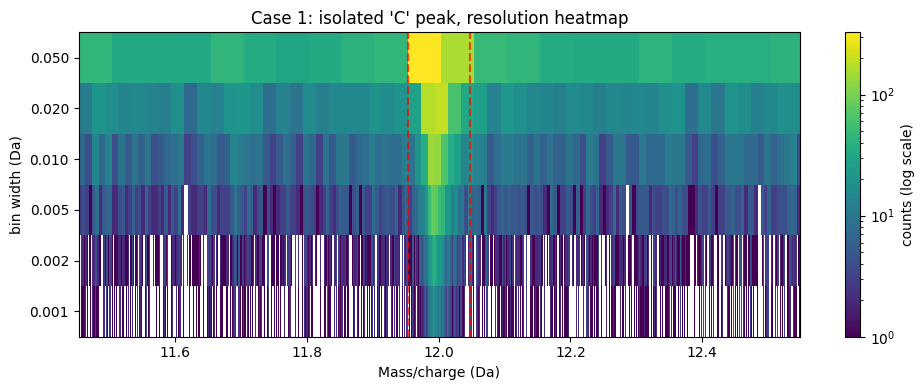

Heatmap grid shape: (6, 3177) (rows=bin widths, cols=mass bins aligned to 0.001 Da)


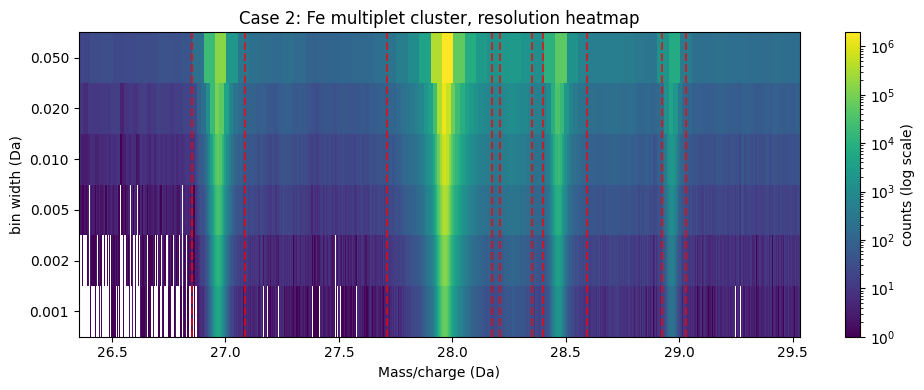

In [9]:
def plot_heatmap(sweep, labels_in_window, title, bin_widths=BIN_WIDTHS):
    finest = bin_widths[0]
    x_fine, _ = sweep[finest]
    n_fine = len(x_fine)

    rows = []
    for w in bin_widths:
        x, counts = sweep[w]
        factor = round(w / finest)
        upsampled = np.repeat(counts, factor)
        if len(upsampled) < n_fine:
            upsampled = np.pad(upsampled, (0, n_fine - len(upsampled)), constant_values=upsampled[-1])
        else:
            upsampled = upsampled[:n_fine]
        rows.append(upsampled)
    grid = np.array(rows)
    print(f"Heatmap grid shape: {grid.shape} (rows=bin widths, cols=mass bins aligned to {finest} Da)")

    fig, ax = plt.subplots(figsize=(10, 4))
    mesh = ax.pcolormesh(x_fine, np.arange(len(bin_widths)), grid,
                          norm=mcolors.LogNorm(vmin=1, vmax=max(grid.max(), 1)),
                          cmap='viridis', shading='nearest')
    ax.set_yticks(np.arange(len(bin_widths)))
    ax.set_yticklabels([f"{w:.3f}" for w in bin_widths])
    ax.set_xlabel("Mass/charge (Da)")
    ax.set_ylabel("bin width (Da)")
    ax.set_title(title)
    for p in labels_in_window:
        ax.axvline(p.start, color='red', linestyle='--', alpha=0.7)
        ax.axvline(p.end, color='red', linestyle='--', alpha=0.7)
    fig.colorbar(mesh, ax=ax, label="counts (log scale)")
    plt.tight_layout()
    plt.show()


plot_heatmap(c_sweep, [peaks[c_idx]], "Case 1: isolated 'C' peak, resolution heatmap")
plot_heatmap(fe_sweep, [peaks[i] for i in fe_cluster_idx], "Case 2: Fe multiplet cluster, resolution heatmap")
